## This notebook launches the LatissCWFSAlign script, meant for the scriptQueue, but via a notebook.
##### This calculates focus offsets for the hexapod (and also decentering corrections)

#### WARNING: This currently requires ts_externalscripts branch **tickets/DM-28423**

In [1]:
import sys
import asyncio
import time

import numpy as np
import logging 
import yaml
import matplotlib.pyplot as plt

from lsst.ts import salobj
from lsst.ts.externalscripts.auxtel.latiss_cwfs_align import LatissCWFSAlign

from lsst.ts.idl.enums.Script import ScriptState

In [38]:
print(1)

1


In [2]:
stream_handler = logging.StreamHandler(sys.stdout)
# if you want logging
logger = logging.getLogger()
logger.addHandler(stream_handler)
logger.level = logging.DEBUG

# turn off logging for matplotlib
mpl_logger = logging.getLogger('matplotlib')
mpl_logger.setLevel(logging.WARNING)

In [3]:
script = LatissCWFSAlign(index=1, remotes=True)  # this essentially calls the init method
# make sure all remotes etc are running
await script.start_task

DEBUG:ATCS:atmcs: Adding all resources.
atmcs: Adding all resources.
DEBUG:ATCS:atptg: Adding all resources.
atptg: Adding all resources.
DEBUG:ATCS:ataos: Adding all resources.
ataos: Adding all resources.
DEBUG:ATCS:atpneumatics: Adding all resources.
atpneumatics: Adding all resources.
DEBUG:ATCS:athexapod: Adding all resources.
athexapod: Adding all resources.
DEBUG:ATCS:atdome: Adding all resources.
atdome: Adding all resources.
DEBUG:ATCS:atdometrajectory: Adding all resources.
atdometrajectory: Adding all resources.
DEBUG:LATISS:atcamera: Adding all resources.
atcamera: Adding all resources.
DEBUG:LATISS:atspectrograph: Adding all resources.
atspectrograph: Adding all resources.
DEBUG:LATISS:atheaderservice: Adding all resources.
atheaderservice: Adding all resources.
DEBUG:LATISS:atarchiver: Adding all resources.
atarchiver: Adding all resources.
INFO:ATDomeTrajectory:Read historical data in 0.01 sec
Read historical data in 0.01 sec
DEBUG:ATDomeTrajectory:Read 1 history items f

In [4]:
# set wrap strategy
# this is required until the ATPtg is updated to not configure the mount for maximum time on target
script.atcs.rem.atptg.cmd_raDecTarget.set(azWrapStrategy=1)  # 1 does not unwrap, 0 unwraps

## Emulate how the scriptQueue launches scripts
##### Start here if re-running the script after a correction

In [39]:
configuration = yaml.safe_dump({"filter": 'RG610', 
                                "grating": 'empty_1',
                                "exposure_time": 20,
                                "dataPath": '/project/shared/auxTel/rerun/quickLook'})
print(configuration)

dataPath: /project/shared/auxTel/rerun/quickLook
exposure_time: 20
filter: RG610
grating: empty_1



In [40]:
# Set script state to UNCONFIGURED
# this is required to run the script a 2nd time but otherwise is a no-op
script.set_state(ScriptState.UNCONFIGURED)
# Configure the script, which puts the ScriptState to CONFIGURED
config_data = script.cmd_configure.DataType()
config_data.config = configuration
await script.do_configure(config_data)

INFO:Script:Using binning factor of 2
Using binning factor of 2


In [ ]:
# ATAOS must be on and corrections enabled, do as follows if required
# await script.atcs.rem.ataos.cmd_enableCorrection.set_start(m1=True, hexapod=True, atspectrograph=True)

In [ ]:
# Target must be on the detector
# Can use this command to slew to target if required
# await script.attcs.slew_object('96 Cet')

In [41]:
# Run this script while taking new data
script.intra_visit_id = None
script.extra_visit_id = None
script.short_timeout = 10
results = await script.arun()

DEBUG:Script:CWFS iteration 1 starting...
CWFS iteration 1 starting...
Intra/Extra images not taken. Running take image sequence.
DEBUG:Script:Moving to intra-focal position
Moving to intra-focal position
DEBUG:LATISS:ENGTEST 0001 - 0001
ENGTEST 0001 - 0001
DEBUG:Script:Moving to extra-focal position
Moving to extra-focal position
DEBUG:Script:Taking extra-focal image
Taking extra-focal image
DEBUG:LATISS:ENGTEST 0001 - 0001
ENGTEST 0001 - 0001
DEBUG:Script:Moving hexapod back to zero offset (in-focus) position
Moving hexapod back to zero offset (in-focus) position
INFO:Script:intraImage expId for target: 2021032300612
intraImage expId for target: 2021032300612
INFO:Script:extraImage expId for target: 2021032300613
extraImage expId for target: 2021032300613
target DDS read queue is filling: 11 of 100 elements
target python read queue is filling: 10 of 100 elements
DEBUG:astro_metadata_translator.headers:Checking for header correction file named LATISS-AT_O_20210323_000612.yaml
Checking

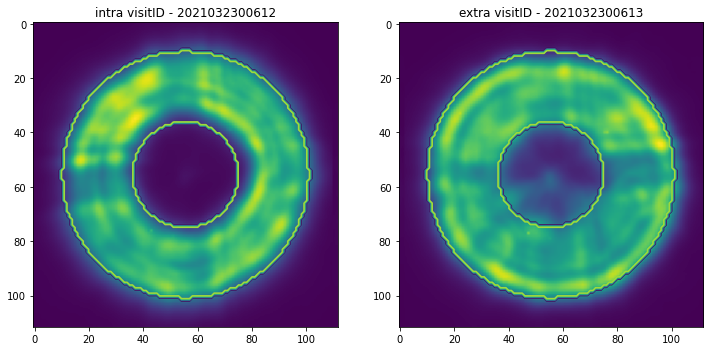

logMessage DDS read queue is filling: 14 of 100 elements


In [42]:
# show donuts and centroids
%matplotlib inline
fig1 = plt.figure(1, figsize=(12,8))
ax11 = fig1.add_subplot(121)
ax11.set_title(f"intra visitID - {script.intra_visit_id}")
ax11.imshow(script.I1[0].image0)
ax11.contour(script.algo.pMask) 
ax12 = fig1.add_subplot(122)
ax12.set_title(f"extra visitID - {script.extra_visit_id}")
ax12.imshow(script.I2[0].image0)
ax12.contour(script.algo.pMask) 

In [36]:
await script.atcs.rem.ataos.cmd_offset.set_start(z=-1.6)

In [33]:
await script.atcs.rem.ataos.cmd_offset.set_start(y=2.0)

In [37]:
await script.latiss.take_object(5.0, 1, filter='RG610', grating='empty_1')

DEBUG:LATISS:Generating group_id
Generating group_id
DEBUG:LATISS:OBJECT 0001 - 0001
OBJECT 0001 - 0001


array([2021032300386])

logMessage DDS read queue is filling: 35 of 100 elements
logMessage DDS read queue is filling: 14 of 100 elements
logMessage DDS read queue is filling: 13 of 100 elements
logMessage DDS read queue is filling: 18 of 100 elements
logMessage DDS read queue is filling: 31 of 100 elements
logMessage DDS read queue is filling: 10 of 100 elements
logMessage DDS read queue is filling: 52 of 100 elements
logMessage DDS read queue is filling: 21 of 100 elements
logMessage DDS read queue is filling: 10 of 100 elements
logMessage DDS read queue is filling: 17 of 100 elements
logMessage DDS read queue is filling: 10 of 100 elements


In [ ]:
# Apply calculated focus offset
calculated_hexapod_focus_offset = results['hex_offset'][2]
print(f'Applying focus offset of {calculated_hexapod_focus_offset}')
await script.atcs.rem.ataos.cmd_offset(z=calculated_hexapod_focus_offset)

# Stop here unless a re-reduction of the doughnuts is required.

#### If you want to re-reduce data then use the below cells

In [ ]:
# Show which files/parameters were taken in the sequence above
print(f'intra_visit_id is {script.intra_visit_id}')
print(f'extra_visit_id is {script.extra_visit_id}')
print(f'angle is {script.angle}')

In [ ]:
# If desired then different filenames can be manually input here
#script.intra_visit_id=2021011900169 
#script.extra_visit_id=2021011900170 
#script.angle=-91.56748047249727

In [ ]:
# reruns reduction part only. ALL 3 fields above must be set! 
rerun_results = await script.run_cwfs()